In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the dataset
df = pd.read_csv('phishing.csv')

In [2]:
df.head()

,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
0,0,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
1,1,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
2,2,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
3,3,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
4,4,-1,0,-1,1,-1,-1,1,1,-1,...,1,1,1,1,1,-1,1,-1,-1,1


In [4]:
df.isnull().sum()

Index                  0
UsingIP                0
LongURL                0
ShortURL               0
Symbol@                0
Redirecting//          0
PrefixSuffix-          0
SubDomains             0
HTTPS                  0
DomainRegLen           0
Favicon                0
NonStdPort             0
HTTPSDomainURL         0
RequestURL             0
AnchorURL              0
LinksInScriptTags      0
ServerFormHandler      0
InfoEmail              0
AbnormalURL            0
WebsiteForwarding      0
StatusBarCust          0
DisableRightClick      0
UsingPopupWindow       0
IframeRedirection      0
AgeofDomain            0
DNSRecording           0
WebsiteTraffic         0
PageRank               0
GoogleIndex            0
LinksPointingToPage    0
StatsReport            0
class                  0
dtype: int64

C:\Users\user\AppData\Local\Temp\ipykernel_42124\985614321.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df, palette='viridis')


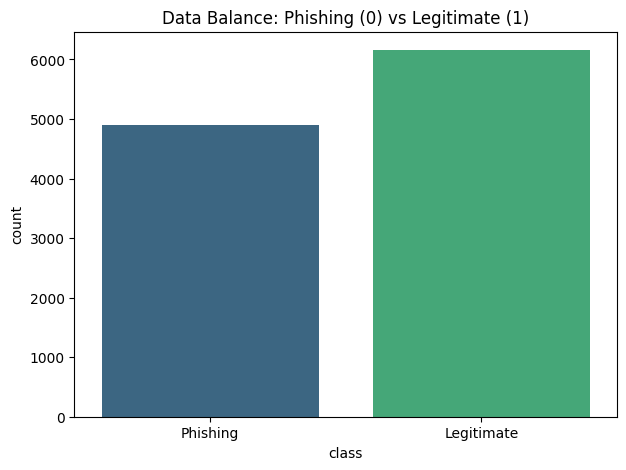

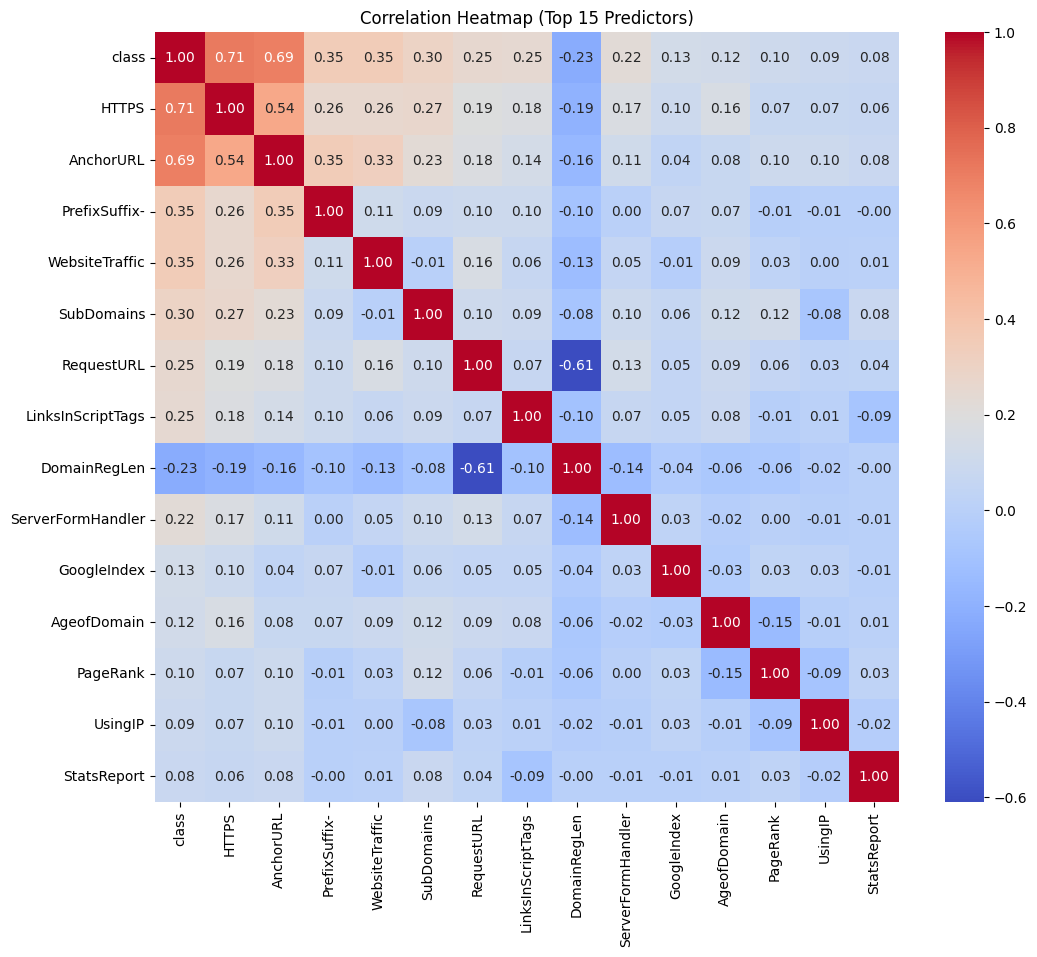

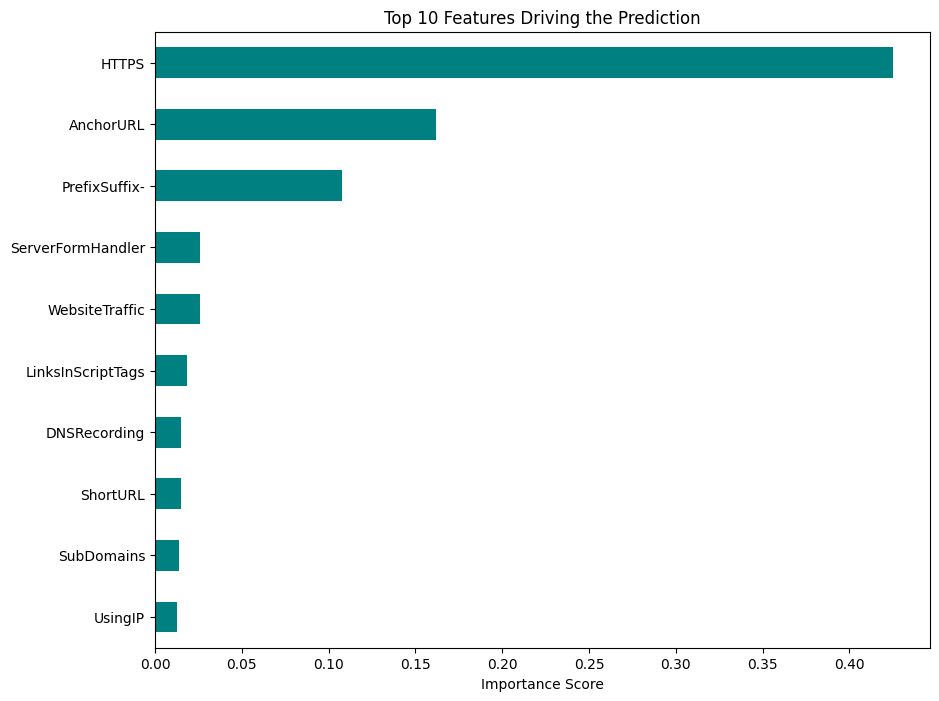

Step 3 Complete! Images saved: class_distribution.png, correlation_heatmap.png, feature_importance.png


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier

# 1. Load and prepare data
df = pd.read_csv('phishing.csv')
df = df.drop(['Index'], axis=1)
df['class'] = df['class'].map({-1: 0, 1: 1})

# --- IMAGE 1: Class Distribution ---
plt.figure(figsize=(7, 5))
sns.countplot(x='class', data=df, palette='viridis')
plt.title('Data Balance: Phishing (0) vs Legitimate (1)')
plt.xticks([0, 1], ['Phishing', 'Legitimate'])
plt.savefig('class_distribution.png')
plt.show()

# --- IMAGE 2: Correlation Heatmap (Top 15 Features) ---
plt.figure(figsize=(12, 10))
# Get the 15 features most correlated with 'class'
top_corr = df.corr()['class'].abs().sort_values(ascending=False).head(15).index
sns.heatmap(df[top_corr].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Top 15 Predictors)')
plt.savefig('correlation_heatmap.png')
plt.show()

# --- IMAGE 3: Feature Importance ---
# We use the winner (XGBoost) to see what it found most important
X = df.drop('class', axis=1)
y = df['class']
model = XGBClassifier()
model.fit(X, y)

feat_importances = pd.Series(model.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 8))
feat_importances.nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title('Top 10 Features Driving the Prediction')
plt.xlabel('Importance Score')
plt.savefig('feature_importance.png')
plt.show()

print("Step 3 Complete! Images saved: class_distribution.png, correlation_heatmap.png, feature_importance.png")

<Figure size 800x600 with 0 Axes>

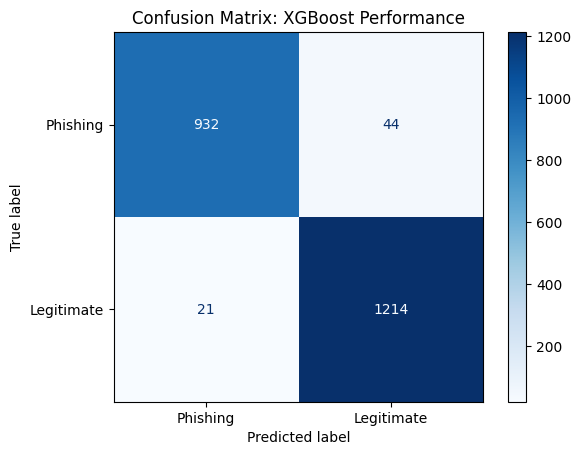

Average Inference Latency: 15.5811 ms per URL


In [8]:
import time
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score

# 1. Confusion Matrix for the Winner (XGBoost)
# Assuming 'best_model' is your XGBoost model from Step 2
y_pred = trained_models["XGBoost"].predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Phishing', 'Legitimate'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix: XGBoost Performance')
plt.savefig('confusion_matrix.png')
plt.show()

# 2. Inference Latency (Mobile Readiness)
# Measure how long it takes to predict 1000 samples
start_time = time.time()
for i in range(1000):
    _ = trained_models["XGBoost"].predict(X_test.iloc[0:1])
end_time = time.time()

avg_latency = (end_time - start_time) / 1000
print(f"Average Inference Latency: {avg_latency*1000:.4f} ms per URL")

In [ ]:
# 3. K-Fold Cross Validation (Stability)
# This takes a bit longer as it trains the model 5 times
print("Performing 5-Fold Cross Validation...")
cv_scores = cross_val_score(trained_models["XGBoost"], X, y, cv=5)
print(f"Cross-Validation Accuracy: {cv_scores.mean()*100:.2f}% (+/- {cv_scores.std()*100:.2f}%)")

In [9]:
print(df.columns.tolist())

['UsingIP', 'LongURL', 'ShortURL', 'Symbol@', 'Redirecting//', 'PrefixSuffix-', 'SubDomains', 'HTTPS', 'DomainRegLen', 'Favicon', 'NonStdPort', 'HTTPSDomainURL', 'RequestURL', 'AnchorURL', 'LinksInScriptTags', 'ServerFormHandler', 'InfoEmail', 'AbnormalURL', 'WebsiteForwarding', 'StatusBarCust', 'DisableRightClick', 'UsingPopupWindow', 'IframeRedirection', 'AgeofDomain', 'DNSRecording', 'WebsiteTraffic', 'PageRank', 'GoogleIndex', 'LinksPointingToPage', 'StatsReport', 'class']


In [10]:
print(df.iloc[0].values)

[ 1  1  1  1  1 -1  0  1 -1  1  1 -1  1  0 -1 -1  1  1  0  1  1  1  1 -1
 -1  0 -1  1  1  1  0]


In [5]:
# 2. Drop the 'Index' column as it's not a feature
df = df.drop(['Index'], axis=1)

# 3. Map the target 'class' from [-1, 1] to [0, 1]
# -1 (Phishing) becomes 0, 1 (Legitimate) remains 1
df['class'] = df['class'].map({-1: 0, 1: 1})

# 4. Separate features (X) and target (y)
X = df.drop('class', axis=1)
y = df['class']

# 5. Split the data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Step 1 Complete!")
print(f"Total samples: {len(df)}")
print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")
print("\nTarget class distribution after mapping (0=Phishing, 1=Legitimate):")
print(y.value_counts())

Step 1 Complete!
Total samples: 11054
Training set size: 8843
Testing set size: 2211

Target class distribution after mapping (0=Phishing, 1=Legitimate):
class
1    6157
0    4897
Name: count, dtype: int64


Training models and calculating AUC-ROC...
Finished training: Logistic Regression
Finished training: Random Forest
Finished training: SVM


C:\Users\user\anaconda3\envs\TrkA\Lib\site-packages\xgboost\training.py:183: UserWarning: [01:36:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Finished training: XGBoost

Step 2 Complete! Updated results with AUC-ROC:
             Algorithm  Accuracy  Precision    Recall  F1-Score   AUC-ROC
0  Logistic Regression  0.933514   0.929700  0.953036  0.941224  0.980419
1        Random Forest  0.969245   0.968675  0.976518  0.972581  0.994938
2                  SVM  0.951153   0.941269  0.973279  0.957006  0.988990
3              XGBoost  0.970602   0.965024  0.982996  0.973927  0.996185


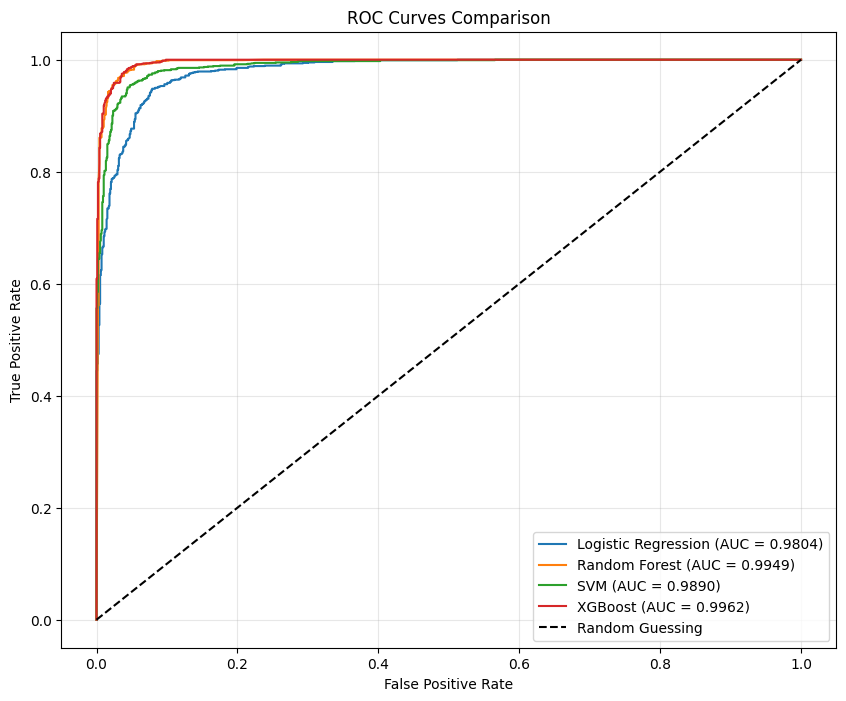


Saved the best model (XGBoost) as 'phishing_model.pkl'.


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# 1. Initialize the 4 models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results_list = []
trained_models = {}

# Prepare for plotting ROC curves
plt.figure(figsize=(10, 8))

print("Training models and calculating AUC-ROC...")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # AUC-ROC requires probability scores instead of binary 0/1
    y_probs = model.predict_proba(X_test)[:, 1]
    
    trained_models[name] = model
    
    # Calculate Metrics
    auc_score = roc_auc_score(y_test, y_probs)
    metrics = {
        "Algorithm": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC-ROC": auc_score
    }
    results_list.append(metrics)
    
    # Generate ROC curve data for plotting
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})')
    
    print(f"Finished training: {name}")

# 2. Display the updated results table
results_df = pd.DataFrame(results_list)
print("\nStep 2 Complete! Updated results with AUC-ROC:")
print(results_df)

# 3. Finalize and show the ROC Curve Plot
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# 4. Save the best model
best_model_name = results_df.sort_values(by="Accuracy", ascending=False).iloc[0]["Algorithm"]
joblib.dump(trained_models[best_model_name], 'phishing_model.pkl')
print(f"\nSaved the best model ({best_model_name}) as 'phishing_model.pkl'.")

In [13]:
!pip install transformers

  Using cached transformers-4.57.3-py3-none-any.whl.metadata (43 kB)
  Using cached huggingface_hub-0.36.0-py3-none-any.whl.metadata (14 kB)
  Using cached regex-2025.11.3-cp313-cp313-win_amd64.whl.metadata (41 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached fsspec-2025.12.0-py3-none-any.whl.metadata (10 kB)
Using cached transformers-4.57.3-py3-none-any.whl (12.0 MB)
Using cached huggingface_hub-0.36.0-py3-none-any.whl (566 kB)
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.7 MB 1.2 MB/s eta 0:00:02
   ----------- ---------------------------- 0.8/2.7 MB 1.4 MB/s eta 0:00:02
   --------------- ------------------------ 1.0/2.7 MB 1.4 MB/s eta 0:00:02
   ---------------

In [14]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("Rostlab/prot_bert")
tokenizer.save_pretrained("./protbert_tokenizer")

None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

C:\Users\user\anaconda3\envs\TrkA\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user\.cache\huggingface\hub\models--Rostlab--prot_bert. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt:   0%|          | 0.00/81.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

('./protbert_tokenizer\\tokenizer_config.json',
 './protbert_tokenizer\\special_tokens_map.json',
 './protbert_tokenizer\\vocab.txt',
 './protbert_tokenizer\\added_tokens.json')